In [ ]:
import numpy as np
from astropy import units as u
from astropy.table import Table
from astropy.time import Time
from WDBinary import WDBinary
from SLBlensing import SLBlensing

from scipy import integrate
from astropy.constants import G, c, M_sun

import matplotlib.pyplot as plt
from matplotlib import gridspec

# KOI-3278

In [ ]:
mass_wd  = 0.634
r_wd = 0.01166 * u.Rsun
l_wd = 0.00120
mass_star = 1.042
r_star = 0.964 * u.Rsun
l_star = 1.0
ecc = 0.0147        # from e cos ω ≈ 0.014713, e sin ω ≈ 0
a  = 0.4605 * u.au
d = 808.0 * u.pc
inc_deg  = 89.6063 * u.deg
omega_deg = 0.0 * u.deg   # e sin ω ≈ 0 means ω ≈ 0 or 180
limb_darkening_star = [0.44, 0.23]
limb_darkening_wd   = [0.0, 0.0]

N=800000

koi_3278 = SLBlensing(
    mass_wd, r_wd, l_wd,
    mass_star, r_star, l_star,
    ecc, a, d, omega=omega_deg, cycles=1.0,
    inc=inc_deg,
    limb_darkening_wd=limb_darkening_wd, limb_darkening_star=limb_darkening_star,
    N=N
)

/Users/wanglm/anaconda3/envs/pygyre_env/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


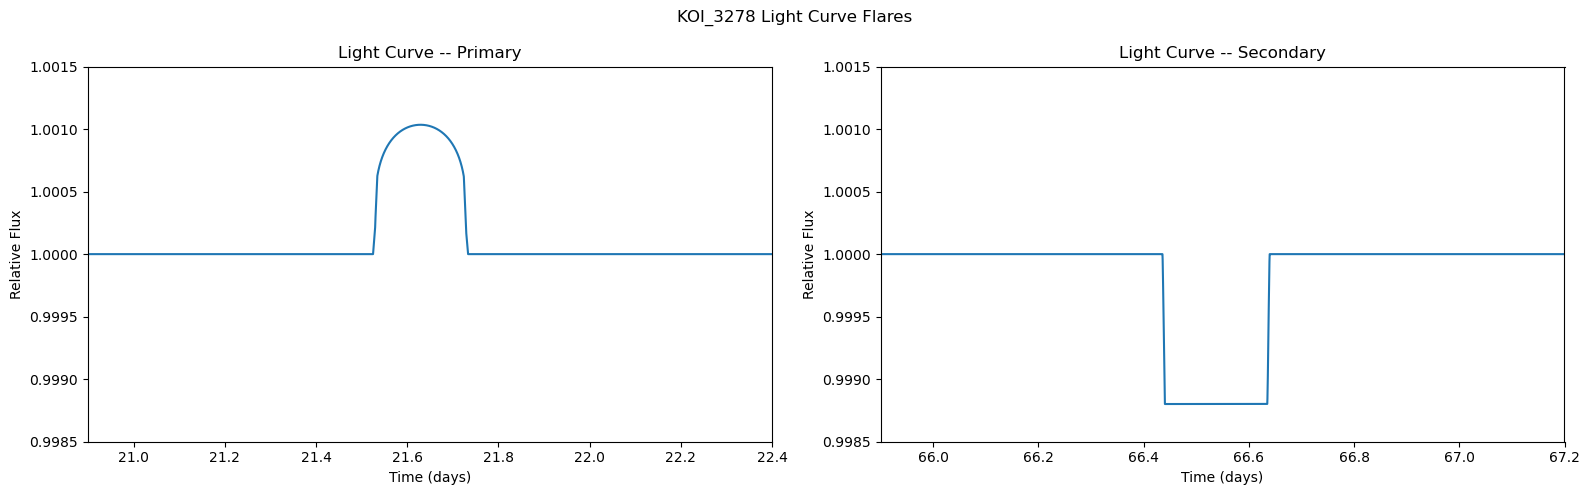

In [3]:
fig = plt.figure(figsize=(16, 5))  
gs = gridspec.GridSpec(1, 2)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])

plt.suptitle("KOI_3278 Light Curve Flares")

ax0.plot((koi_3278.t).to(u.day).value, koi_3278.geo_flux / koi_3278.base_flux)
ax0.set_xlabel("Time (days)")
ax0.set_ylabel("Relative Flux")
ax0.set_title("Light Curve -- Primary")
ax0.set_xlim(20.9, 22.4)
ax0.set_ylim(0.9985, 1.0015)

ax1.plot((koi_3278.t).to(u.day).value, koi_3278.geo_flux / koi_3278.base_flux)
ax1.set_xlabel("Time (days)")
ax1.set_ylabel("Relative Flux")
ax1.set_title("Light Curve -- Secondary")
ax1.set_xlim(65.9, 67.2)
ax1.set_ylim(0.9985, 1.0015)

plt.tight_layout()
plt.show()

In [4]:
plt.rcParams.update({
    "font.size": 18,              # Base font size
    "axes.titlesize": 15,         # Title size
    "axes.labelsize": 15,         # Axis label size
    "xtick.labelsize": 12,        # Tick label size
    "ytick.labelsize": 12,
    "legend.fontsize": 18,        # Legend font size
    "figure.titlesize": 25       # Suptitle size
})

In [5]:
from numpy import size, zeros, where, arccos, sqrt, pi, log

def ellke(k):
    m1=1.-k**2
    logm1 = log(m1)
    a1=0.44325141463; a2=0.06260601220; a3=0.04757383546; a4=0.01736506451
    b1=0.24998368310; b2=0.09200180037; b3=0.04069697526; b4=0.00526449639
    ee1=1.+m1*(a1+m1*(a2+m1*(a3+m1*a4)))
    ee2=m1*(b1+m1*(b2+m1*(b3+m1*b4)))*(-logm1)
    ek = ee1+ee2
    a0=1.38629436112; a1=0.09666344259; a2=0.03590092383; a3=0.03742563713; a4=0.01451196212
    b0=0.5; b1=0.12498593597; b2=0.06880248576; b3=0.03328355346; b4=0.00441787012
    ek1=a0+m1*(a1+m1*(a2+m1*(a3+m1*a4)))
    ek2=(b0+m1*(b1+m1*(b2+m1*(b3+m1*b4))))*logm1
    kk = ek1-ek2
    return [ek,kk]

def ellpic_bulirsch(n,k):
    kc=sqrt(1.-k**2); p=n+1.
    if(min(p) < 0.):
        print('Negative p')
    m0=1.; c=1.; p=sqrt(p); d=1./p; e=kc
    while 1:
        f = c; c = d/p+c; g = e/p; d = 2.*(f*g+d)
        p = g + p; g = m0; m0 = kc + m0
        if max(abs(1.-kc/g)) > 1.e-8:
            kc = 2*sqrt(e); e=kc*m0
        else:
            return 0.5*pi*(c*m0+d)/(m0*(m0+p))

def mandel_agol(z, u1, u2, p0):
    nz = size(z)
    lambdad = zeros(nz); etad = zeros(nz); lambdae = zeros(nz)
    omega = 1.-u1/3.-u2/6.
    tol = 1e-14
    p = abs(p0)
    z = where(abs(p-z) < tol, p, z)
    z = where(abs((p-1)-z) < tol, p-1., z)
    z = where(abs((1-p)-z) < tol, 1.-p, z)
    z = where(z < tol, 0., z)
    x1=(p-z)**2.; x2=(p+z)**2.; x3=p**2.-z**2.
    if p <= 0.:
        return zeros(nz) + 1.
    notusedyet = where(z < (1. + p))[0]
    if size(notusedyet) == 0:
        return 1.-((1.-u1-2.*u2)*lambdae+(u1+2.*u2)*(lambdad+2./3.*(p > z))+u2*etad)/omega
    if p >= 1.:
        occulted = where(z[notusedyet] <= p-1.)
        if size(occulted) != 0:
            ndxuse = notusedyet[occulted]
            etad[ndxuse] = 0.5; lambdae[ndxuse] = 1.
            notused2 = where(z[notusedyet] > p-1)
            if size(notused2) == 0:
                return 1.-((1.-u1-2.*u2)*lambdae+(u1+2.*u2)*(lambdad+2./3.*(p > z))+u2*etad)/omega
            notusedyet = notusedyet[notused2]
    inegressuni = where((z[notusedyet] >= abs(1.-p)) & (z[notusedyet] < 1.+p))
    if size(inegressuni) != 0:
        ndxuse = notusedyet[inegressuni]
        tmp = (1.-p**2.+z[ndxuse]**2.)/2./z[ndxuse]
        tmp = where(tmp > 1.,1.,tmp); tmp = where(tmp < -1.,-1.,tmp)
        kap1 = arccos(tmp)
        tmp = (p**2.+z[ndxuse]**2-1.)/2./p/z[ndxuse]
        tmp = where(tmp > 1.,1.,tmp); tmp = where(tmp < -1.,-1.,tmp)
        kap0 = arccos(tmp)
        tmp = 4.*z[ndxuse]**2-(1.+z[ndxuse]**2-p**2)**2
        tmp = where(tmp < 0,0,tmp)
        lambdae[ndxuse] = (p**2*kap0+kap1 - 0.5*sqrt(tmp))/pi
        etad[ndxuse] = 1./2./pi*(kap1+p**2*(p**2+2.*z[ndxuse]**2)*kap0-\
           (1.+5.*p**2+z[ndxuse]**2)/4.*sqrt((1.-x1[ndxuse])*(x2[ndxuse]-1.)))
    ocltor = where(z[notusedyet] == p)
    if size(ocltor) != 0:
        ndxuse = notusedyet[ocltor]
        if p < 0.5:
            q=2.*p; Ek,Kk = ellke(q)
            lambdad[ndxuse] = 1./3.+2./9./pi*(4.*(2.*p**2-1.)*Ek+(1.-4.*p**2)*Kk)
            etad[ndxuse] = p**2/2.*(p**2+2.*z[ndxuse]**2)
            lambdae[ndxuse] = p**2
        elif p > 0.5:
            q=0.5/p; Ek,Kk = ellke(q)
            lambdad[ndxuse] = 1./3.+16.*p/9./pi*(2.*p**2-1.)*Ek-(32.*p**4-20.*p**2+3.)/9./pi/p*Kk
        else:
            lambdad[ndxuse] = 1./3.-4./pi/9.; etad[ndxuse] = 3./32.
        notused3 = where(z[notusedyet] != p)
        if size(notused3) == 0:
            return 1.-((1.-u1-2.*u2)*lambdae+(u1+2.*u2)*(lambdad+2./3.*(p > z))+u2*etad)/omega
        notusedyet = notusedyet[notused3]
    inegress = where(((z[notusedyet] > 0.5+abs(p-0.5)) & (z[notusedyet] < 1.+p)) | \
                     ((p > 0.5) & (z[notusedyet] > abs(1.-p)) & (z[notusedyet] < p)))
    if size(inegress) != 0:
        ndxuse = notusedyet[inegress]
        q=sqrt((1.-x1[ndxuse])/(x2[ndxuse]-x1[ndxuse]))
        Ek,Kk = ellke(q); n=1./x1[ndxuse]-1.
        lambdad[ndxuse]=2./9./pi/sqrt(x2[ndxuse]-x1[ndxuse])*\
                         (((1.-x2[ndxuse])*(2.*x2[ndxuse]+x1[ndxuse]-3.)-\
                           3.*x3[ndxuse]*(x2[ndxuse]-2.))*Kk+(x2[ndxuse]-\
                           x1[ndxuse])*(z[ndxuse]**2+7.*p**2-4.)*Ek-\
                          3.*x3[ndxuse]/x1[ndxuse]*ellpic_bulirsch(n,q))
        notused4 = where(((z[notusedyet] <= 0.5+abs(p-0.5)) | (z[notusedyet] >= 1.+p)) & \
                         ((p <= 0.5) | (z[notusedyet] <= abs(1.-p)) | (z[notusedyet] >= p)))
        if size(notused4) == 0:
            return 1.-((1.-u1-2.*u2)*lambdae+(u1+2.*u2)*(lambdad+2./3.*(p > z))+u2*etad)/omega
        notusedyet = notusedyet[notused4]
    if p < 1.:
        inside = where(z[notusedyet] <= (1.-p))
        if size(inside) != 0:
            ndxuse = notusedyet[inside]
            etad[ndxuse] = p**2/2.*(p**2+2.*z[ndxuse]**2)
            lambdae[ndxuse] = p**2
            edge = where(z[ndxuse] == 1.-p)
            if size(edge[0]) != 0:
                lambdad[ndxuse[edge]] = 2./3./pi*arccos(1.-2.*p)-4./9./pi*sqrt(p*(1.-p))*(3.+2.*p-8.*p**2)
                if p > 0.5:
                    lambdad[ndxuse[edge]] -= 2./3.
                notused6 = where(z[ndxuse] != 1.-p)
                if size(notused6) == 0:
                    return 1.-((1.-u1-2.*u2)*lambdae+(u1+2.*u2)*(lambdad+2./3.*(p > z))+u2*etad)/omega
                ndxuse = ndxuse[notused6[0]]
            origin = where(z[ndxuse] == 0)
            if size(origin) != 0:
                lambdad[ndxuse[origin]] = -2./3.*(1.-p**2)**1.5
                notused7 = where(z[ndxuse] != 0)
                if size(notused7) == 0:
                    return 1.-((1.-u1-2.*u2)*lambdae+(u1+2.*u2)*(lambdad+2./3.*(p > z))+u2*etad)/omega
                ndxuse = ndxuse[notused7[0]]
            q=sqrt((x2[ndxuse]-x1[ndxuse])/(1.-x1[ndxuse]))
            n=x2[ndxuse]/x1[ndxuse]-1.; Ek,Kk = ellke(q)
            lambdad[ndxuse] = 2./9./pi/sqrt(1.-x1[ndxuse])*\
                              ((1.-5.*z[ndxuse]**2+p**2+x3[ndxuse]**2)*Kk+\
                               (1.-x1[ndxuse])*(z[ndxuse]**2+7.*p**2-4.)*Ek-\
                               3.*x3[ndxuse]/x1[ndxuse]*ellpic_bulirsch(n,q))
    return 1.-((1.-u1-2.*u2)*lambdae+(u1+2.*u2)*(lambdad+2./3.*(p > z))+u2*etad)/omega


def kruse_agol_model(t_days,
                     period = 88.180519,
                     ttran  = 21.65,
                     ecosw  =  0.014714,
                     esinw  = -0.000070,
                     b      =  0.705043,
                     M1     =  1.038986,
                     M2     =  0.631343,
                     R1     =  0.964,
                     R2     =  0.01166,
                     F2F1   =  0.00120,
                     u1     =  0.44,
                     u2     =  0.23,
                     ):
    t = np.asarray(t_days)
    e     = np.sqrt(ecosw**2 + esinw**2)
    omega = np.arctan2(esinw, ecosw)
    a_m   = ((period*86400.)**2 * 6.67e-11 * (M1+M2) * 1.988e30 / (4.*np.pi**2))**(1./3.)
    a     = (a_m / 6.955e8) / R1   # in units of R1
    inc   = np.arccos(b / a)
    rrat  = R2 / R1

    edif = 1. - e**2
    fcen = np.pi/2. - omega
    tau  = (ttran + np.sqrt(edif)*period/(2.*np.pi) *
            (e*np.sin(fcen)/(1.+e*np.cos(fcen))
             - 2./np.sqrt(edif)*np.arctan(np.sqrt(edif)*np.tan(fcen/2.)/(1.+e))))

    n      = 2.*np.pi / period
    M_anom = (n*(t - tau)) % (2.*np.pi)
    E      = M_anom.copy()
    for _ in range(50):
        dE = (E - e*np.sin(E) - M_anom) / (1. - e*np.cos(E))
        E -= dE
        if np.max(np.abs(dE)) < 1e-10:
            break

    tanf2 = np.sqrt((1.+e)/(1.-e)) * np.tan(E/2.)
    fanom = (np.arctan(tanf2)*2.) % (2.*np.pi)

    r        = a*(1.-e**2) / (1.+e*np.cos(fanom))
    projdist = r*np.sqrt(1. - np.sin(omega+fanom)**2 * np.sin(inc)**2)
    Z        = r*np.sin(omega+fanom)*np.sin(inc)

    # lensing: Z in units of R1 = Z_solar/R1_solar
    lensdep = 1.6984903e-5 * M2 * np.abs(Z) - rrat**2
    lensdep = lensdep / rrat**2 + 1.

    F1t = np.ones(len(t))
    F2t = np.ones(len(t)) * F2F1

    # Transit: WD in front of star
    transit_mask = (projdist < 1. + rrat) & (Z > 0.)
    if transit_mask.any():
        pd    = projdist[transit_mask]
        ldark = mandel_agol(pd, u1, u2, rrat)
        F1t[transit_mask] *= (ldark + (1. - ldark) * lensdep[transit_mask])

    # Occultation: star in front of WD
    occ_mask = (projdist < 1. + rrat) & (Z < 0.)
    if occ_mask.any():
        pd = projdist[occ_mask]
        ldark = mandel_agol(pd/rrat, 0., 0., 1./rrat)
        F2t[occ_mask] *= ldark

    return (F1t + F2t) / (1. + F2F1)

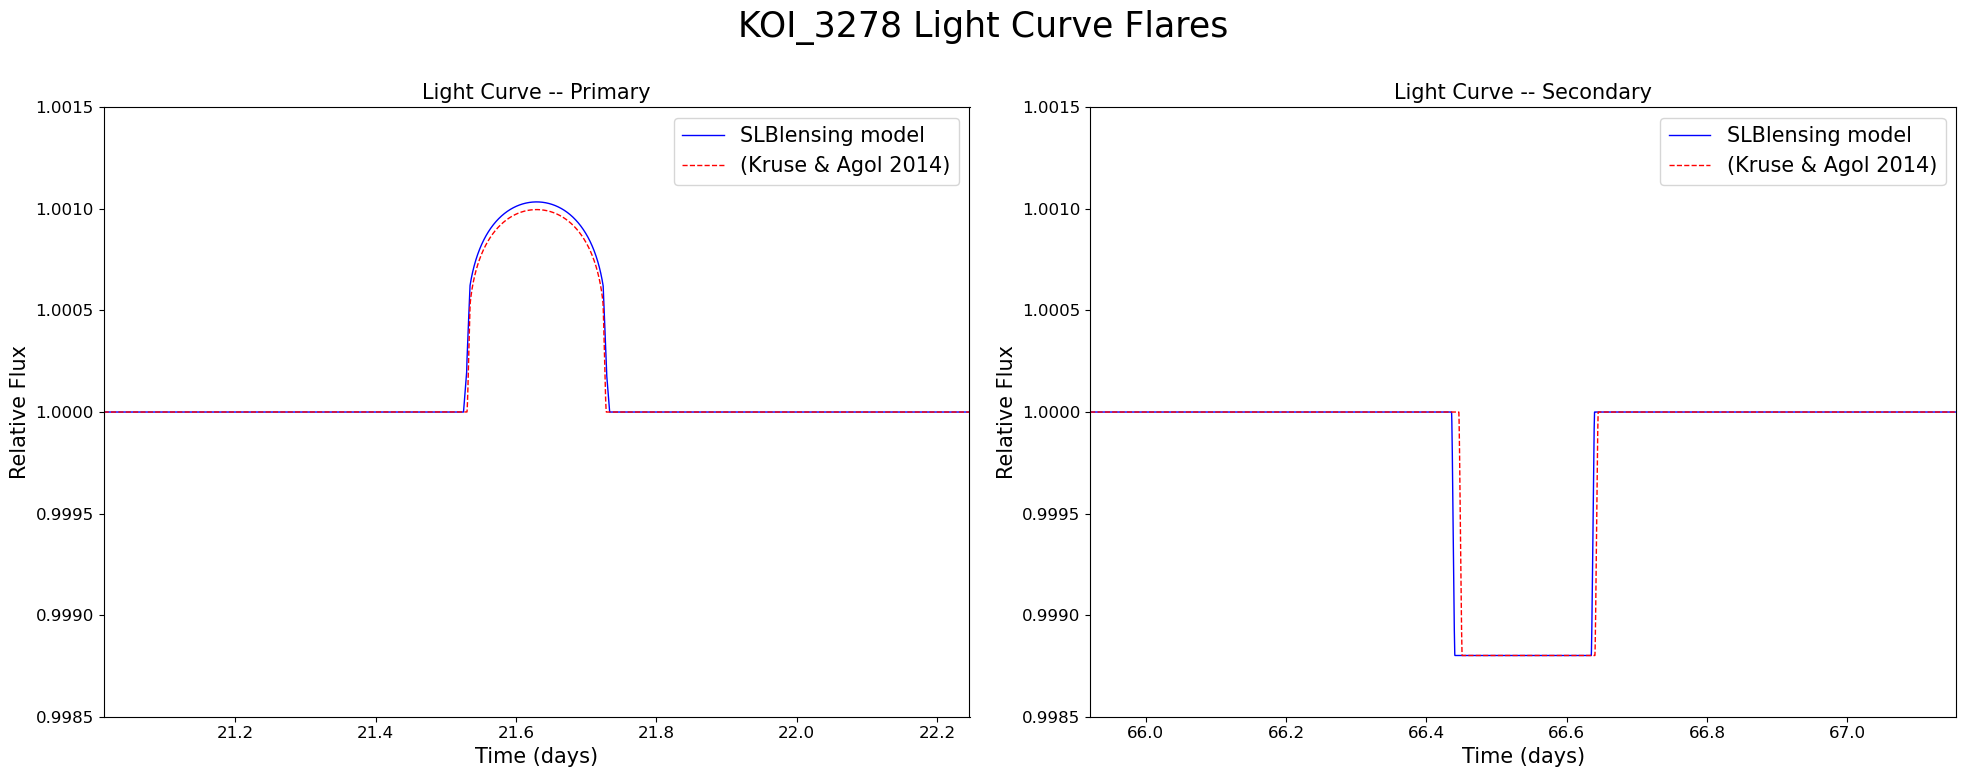

In [6]:
# find your model's pulse center precisely
time = (koi_3278.t).to(u.day).value
frac = koi_3278.geo_flux / koi_3278.base_flux
tra_center = time[np.argmax(frac)]

frac_ka = kruse_agol_model(
    time,
    period = 88.180519,
    ttran  = tra_center,  # exactly aligned to your pulse peak
    ecosw  =  0.014714,
    esinw  = -0.000070,
    b      =  0.705043,
    M1     =  1.038986,
    M2     =  0.631343,
    R1     =  0.964,
    R2     =  0.01166,
    F2F1   =  0.00120,
    u1     =  0.44,
    u2     =  0.23,
)

transit_mask = frac > 1
occ_mask = frac < 1

tra_mid = np.median(time[transit_mask])
occ_mid = np.median(time[occ_mask])

dt = np.abs(time[1] - time[0])
change = 0.007 * koi_3278.N * dt

fig = plt.figure(figsize=(20, 8))  
gs = gridspec.GridSpec(1, 2)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
plt.suptitle("KOI_3278 Light Curve Flares")

ax0.plot(time, frac,    'b-',  lw=1.0, label='SLBlensing model')
ax0.plot(time, frac_ka, 'r--', lw=1.0, label='(Kruse & Agol 2014)')
ax0.set_xlabel("Time (days)")
ax0.set_ylabel("Relative Flux")
ax0.set_title("Light Curve -- Primary")
ax0.set_xlim(tra_mid - change, tra_mid + change)
ax0.set_ylim(0.9985, 1.0015)
ax0.legend(fontsize=15)

ax1.plot(time, frac,    'b-',  lw=1.0, label='SLBlensing model')
ax1.plot(time, frac_ka, 'r--', lw=1.0, label='(Kruse & Agol 2014)')
ax1.set_xlabel("Time (days)")
ax1.set_ylabel("Relative Flux")
ax1.set_title("Light Curve -- Secondary")
ax1.set_xlim(occ_mid - change, occ_mid + change)
ax1.set_ylim(0.9985, 1.0015)
ax1.legend(fontsize=15)

plt.tight_layout()
plt.show()

# KIC 3835482

In [ ]:
# KIC 3835482 | P = 683.27 days
mass_wd   = 0.62             
r_wd      = 0.01228 * u.Rsun 
l_wd      = 0.00055          
mass_star = 1.52            
r_star    = 2.28 * u.Rsun   
l_star    = 6.80            
ecc       = 0.062           
a         = 1.957 * u.au    
d         = 1150.0 * u.pc    
inc_deg   = 89.9 * u.deg     
omega_deg = 4.0 * u.deg      

limb_darkening_star = [0.391, 0.226]
limb_darkening_wd   = [0.288, 0.241]

kic_3835482 = SLBlensing(
    mass_wd, r_wd, l_wd,
    mass_star, r_star, l_star,
    ecc, a, d, omega=omega_deg, cycles=1.0,
    inc=inc_deg,
    limb_darkening_wd=limb_darkening_wd, limb_darkening_star=limb_darkening_star,
    N=N
)

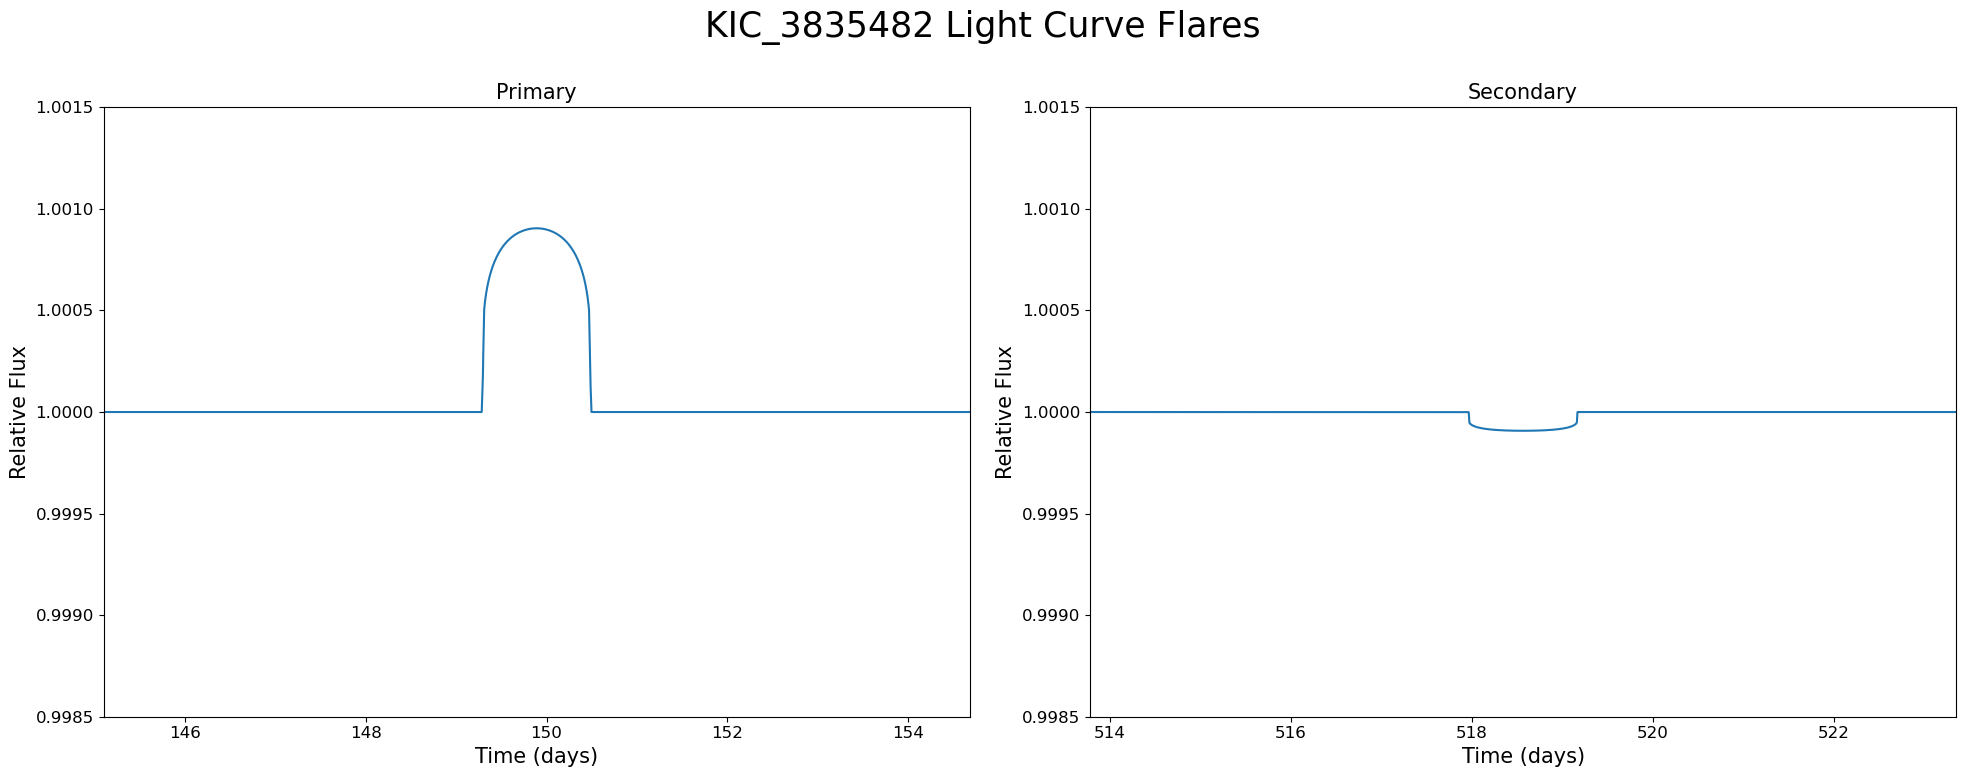

In [8]:
kic_3835482.light_curve_plotter("KIC_3835482")

# KIC 6233093

In [ ]:
# KIC 6233093 | P = 727.98 days
mass_wd   = 0.61             
r_wd      = 0.01241 * u.Rsun
l_wd      = 0.00057
mass_star = 1.27             
r_star    = 2.32 * u.Rsun
l_star    = 6.26             
ecc       = 0.123       
a         = 1.955 * u.au
d         = 1430.0 * u.pc    
inc_deg   = 89.9 * u.deg   
omega_deg = 112.0 * u.deg   

limb_darkening_star = [0.421, 0.207]
limb_darkening_wd   = [0.288, 0.241]

kic_6233093 = SLBlensing(
    mass_wd, r_wd, l_wd,
    mass_star, r_star, l_star,
    ecc, a, d, omega=omega_deg, cycles=1.0,
    inc=inc_deg,
    limb_darkening_wd=limb_darkening_wd, limb_darkening_star=limb_darkening_star,
    N=N
)

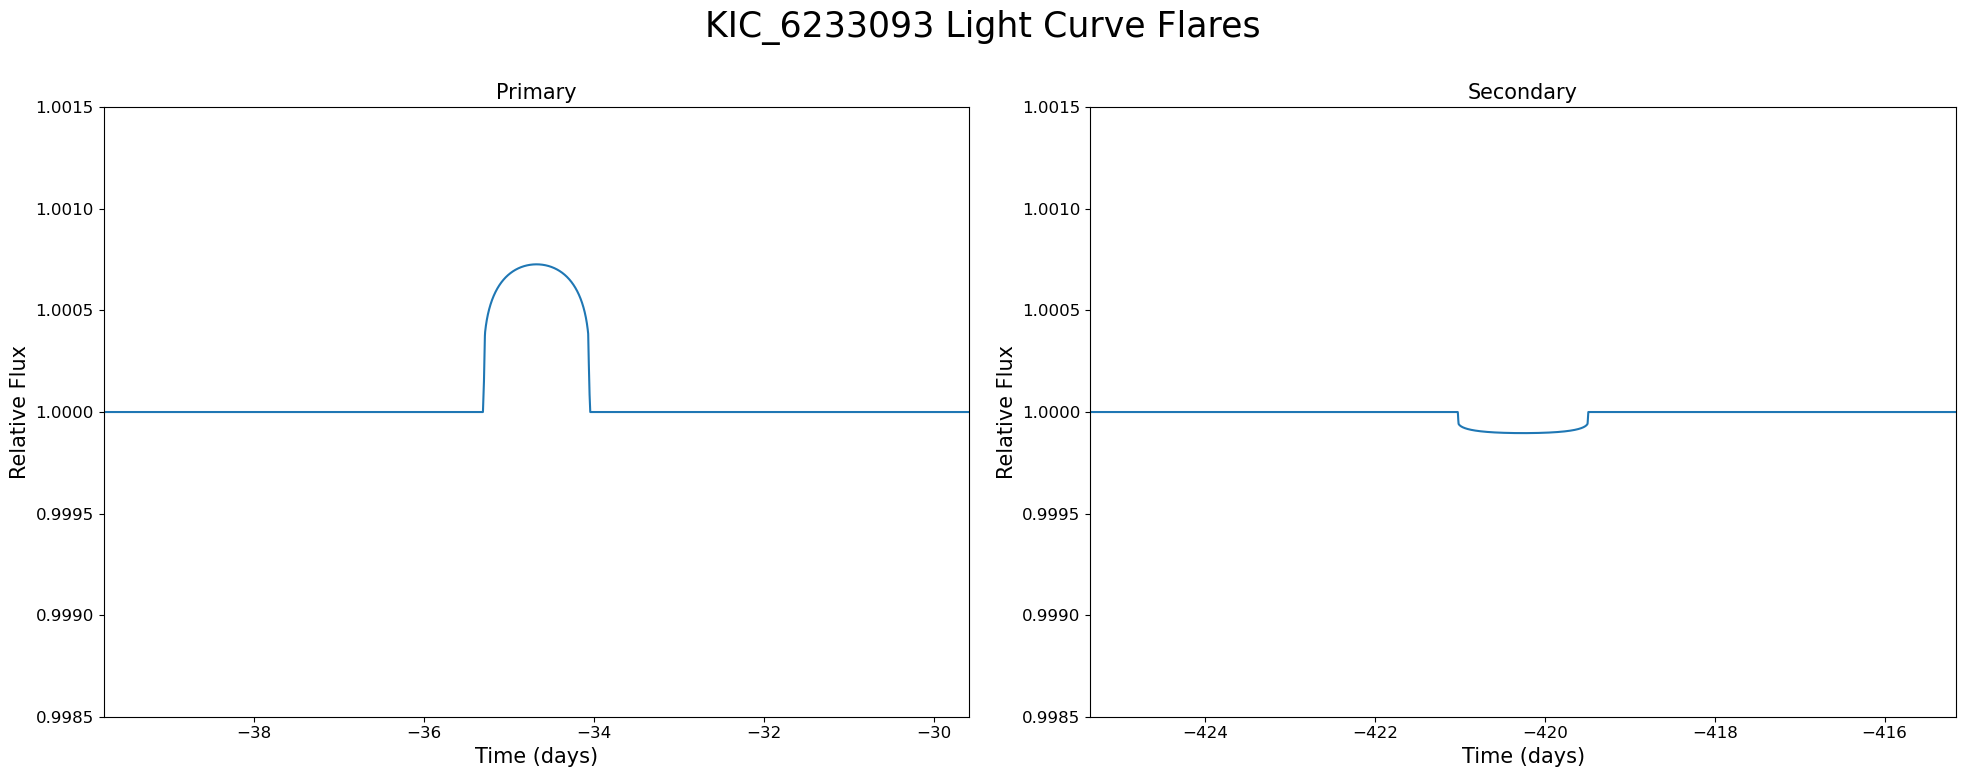

In [14]:
kic_6233093.light_curve_plotter("KIC_6233093")

# KIC 12254688

In [ ]:
# KIC 12254688 | P = 418.72 days  (F2V primary)
mass_wd   = 0.56             
r_wd      = 0.01308 * u.Rsun
l_wd      = 0.00063
mass_star = 1.37             
r_star    = 2.08 * u.Rsun
l_star    = 8.30            
ecc       = 0.180  
a         = 1.364 * u.au
d         = 1200.0 * u.pc    
inc_deg   = 89.9 * u.deg   
omega_deg = 128.0 * u.deg    

limb_darkening_star = [0.301, 0.268]
limb_darkening_wd   = [0.286, 0.241]

kic_12254688 = SLBlensing(
    mass_wd, r_wd, l_wd,
    mass_star, r_star, l_star,
    ecc, a, d, omega=omega_deg, cycles=1.0,
    inc=inc_deg,
    limb_darkening_wd=limb_darkening_wd, limb_darkening_star=limb_darkening_star,
    N=N
)

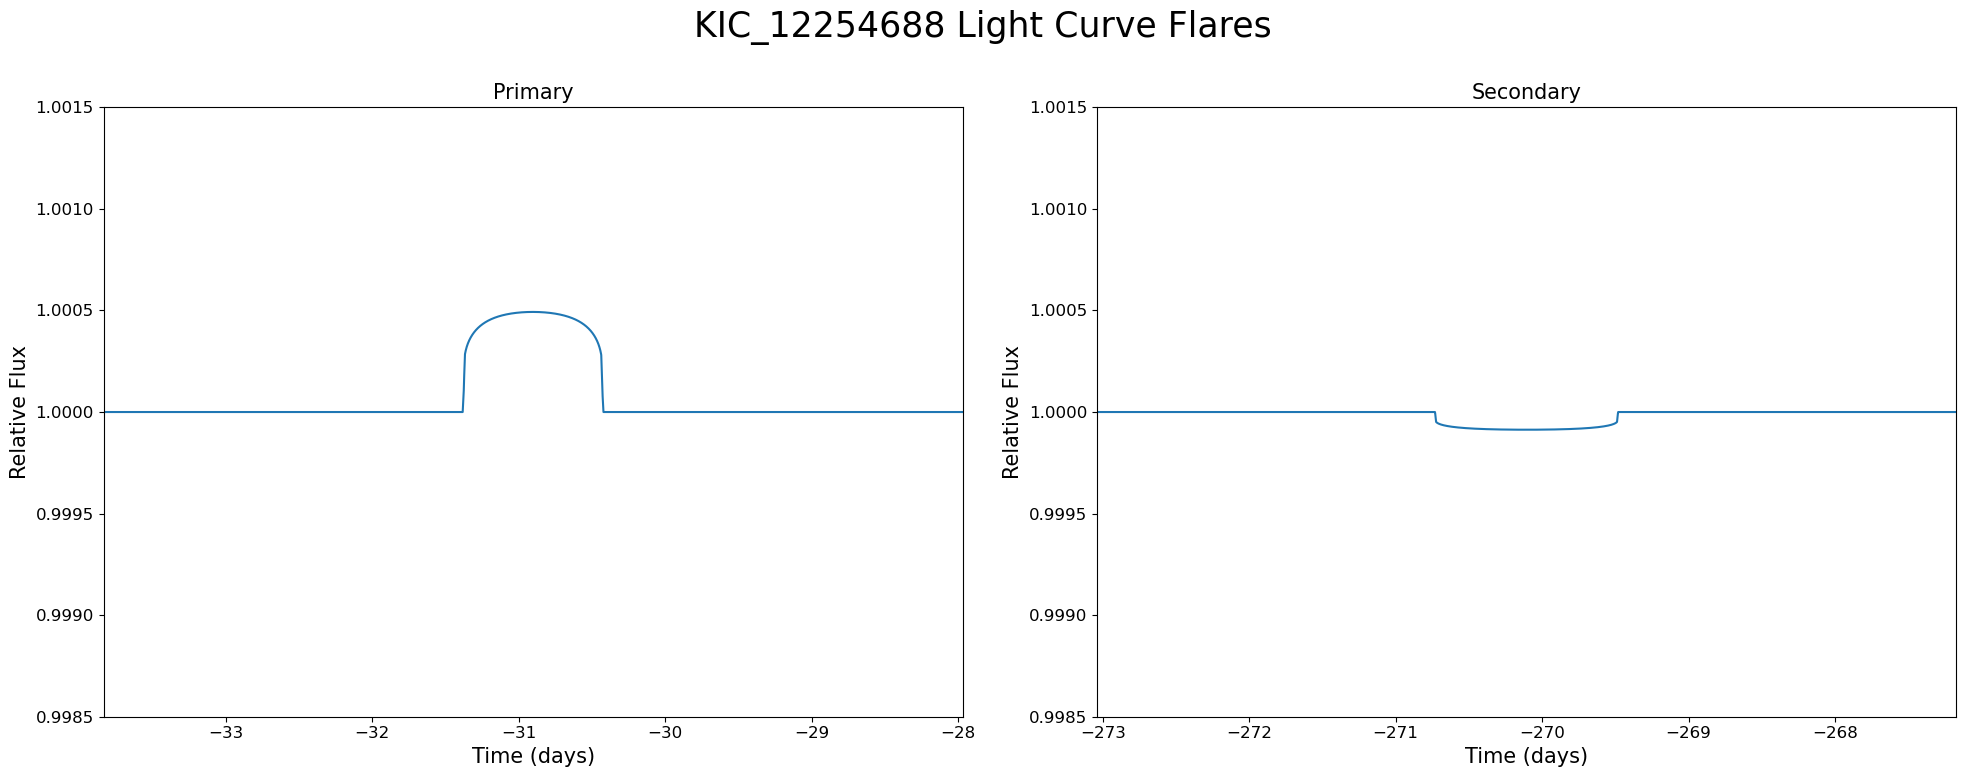

In [15]:
kic_12254688.light_curve_plotter("KIC_12254688")